In [15]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "Apple Maturity Models").exists():
    REPO_ROOT = REPO_ROOT.parent

YOLO_MODEL_PATH = REPO_ROOT / "Apple Maturity Models" / "Apple detection model" / "apple_yolo11n_120_best.pt"
MATURITY_MODEL_PATH = REPO_ROOT / "Apple Maturity Models" / "Apple maturity model"

IMG_SIZE = 224
YOLO_CONF = 0.25
CLASS_NAMES = ["unripe","semi-ripe","ripe"]

print("YOLO path:",YOLO_MODEL_PATH)
print("Maturity model:", MATURITY_MODEL_PATH)

YOLO path: D:\NTI\Project\Smart Precision Agriculture\Models\apple_yolo11n_120_best.pt
Maturity model: D:\NTI\Project\Smart Precision Agriculture\Final apple maturity model


In [16]:
import tensorflow as tf
from ultralytics import YOLO

yolo_model = YOLO(str(YOLO_MODEL_PATH))
print("YOLO loaded successfully")

maturity_model = tf.saved_model.load(str(MATURITY_MODEL_PATH))
infer = maturity_model.signatures["serving_default"]

print("MATURITY MODEL LOADED SUCCESSFULLY")

YOLO loaded successfully
MATURITY MODEL LOADED SUCCESSFULLY


In [17]:
import io
import requests
import tempfile
import numpy as np
from PIL import Image,ImageDraw

def load_test_image(source):
    if not (isinstance(source,str) and source.startswith(("http://","https://"))):
        path = Path(source)
        if not path.exists():
            raise FileNotFoundError(f"Image not found:\n{path}")
        return Image.open(path).convert("RGB"),str(path)

    response = requests.get(source,timeout=30,headers={"User-Agent":"Mozilla/5.0"})
    response.raise_for_status()
    image = Image.open(io.BytesIO(response.content)).convert("RGB")

    temp_file = tempfile.NamedTemporaryFile(suffix=".jpg",delete=False)
    temp_path = temp_file.name
    image.save(temp_path,format="JPEG")
    temp_file.close()

    return image,temp_path

def prepare_image(image):
    image = image.convert("RGB")
    image = image.resize((IMG_SIZE,IMG_SIZE))
    return np.asarray(image,dtype=np.float32)

def run_test(image_source):
    original_image,yolo_source_path = load_test_image(image_source)

    results = yolo_model.predict(
        source=[yolo_source_path],
        imgsz=640,conf=YOLO_CONF,
        save=False,verbose=False
    )

    result = results[0]

    if result.boxes is None or len(result.boxes) == 0:
        print("YOLO returned no boxes for this image.")
        return original_image,original_image.copy(),[]

    xyxy = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()

    boxed_tree = original_image.copy()
    draw = ImageDraw.Draw(boxed_tree)

    apple_batch = []
    tree_batch = []
    box_data = []

    for box,score in zip(xyxy,confs):
        x1,y1,x2,y2 = map(int,box)

        x1 = max(0,min(x1,original_image.width-1))
        y1 = max(0,min(y1,original_image.height-1))
        x2 = max(0,min(x2,original_image.width))
        y2 = max(0,min(y2,original_image.height))

        if x2 <= x1 or y2 <= y1:
            continue

        draw.rectangle([x1,y1,x2,y2],outline="red",width=3)

        apple_crop = original_image.crop((x1,y1,x2,y2))

        apple_batch.append(prepare_image(apple_crop))
        tree_batch.append(prepare_image(boxed_tree))

        box_data.append({
            "box":[x1,y1,x2,y2],
            "yolo_confidence":float(score)
        })

    apple_batch = np.asarray(apple_batch,dtype=np.float32)
    tree_batch = np.asarray(tree_batch,dtype=np.float32)

    output = infer(
        apple_input=tf.convert_to_tensor(apple_batch),
        tree_input=tf.convert_to_tensor(tree_batch)
    )

    probabilities = list(output.values())[0].numpy()

    predictions = []

    for i,probs in enumerate(probabilities):
        class_id = int(np.argmax(probs))

        predictions.append({
            "box":box_data[i]["box"],
            "yolo_confidence":box_data[i]["yolo_confidence"],
            "maturity":CLASS_NAMES[class_id],
            "maturity_confidence":float(probs[class_id]),
            "probabilities":{
                CLASS_NAMES[j]:float(probs[j])
                for j in range(3)
            }
        })

    return original_image,boxed_tree,predictions

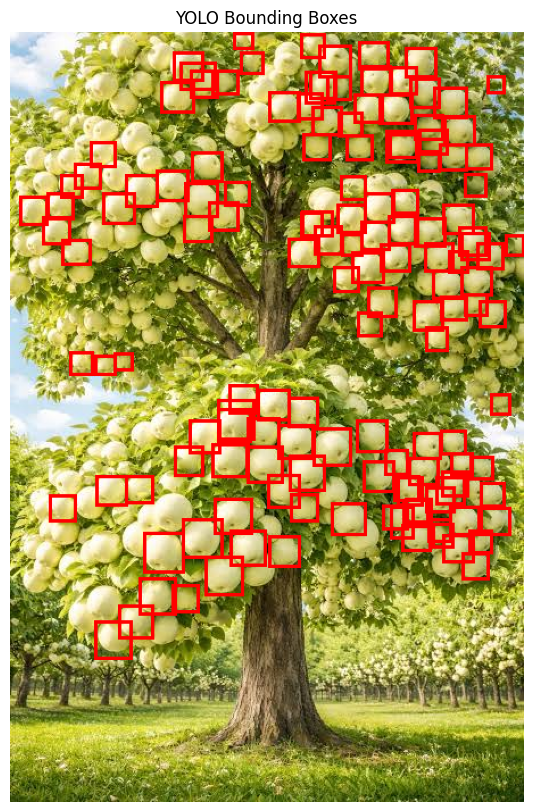

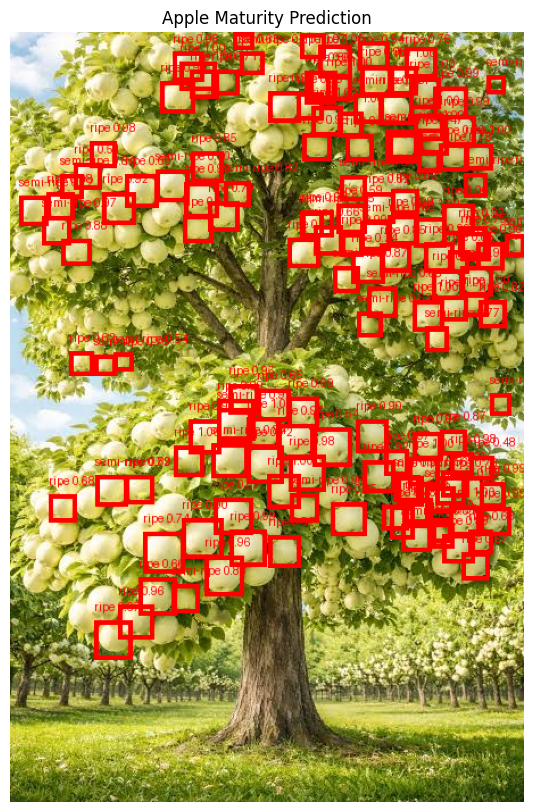

MATURITY RESULTS

Box 1
Bounding box: [159, 105, 187, 132]
YOLO confidence: 0.9326
Maturity: ripe
Maturity confidence: 0.8481
Probabilities: {'unripe': 0.0005, 'semi-ripe': 0.1515, 'ripe': 0.8481}

Box 2
Bounding box: [266, 348, 300, 382]
YOLO confidence: 0.9213
Maturity: ripe
Maturity confidence: 0.541
Probabilities: {'unripe': 0.0025, 'semi-ripe': 0.4565, 'ripe': 0.541}

Box 3
Bounding box: [337, 390, 360, 413]
YOLO confidence: 0.8936
Maturity: semi-ripe
Maturity confidence: 0.5615
Probabilities: {'unripe': 0.0004, 'semi-ripe': 0.5615, 'ripe': 0.438}

Box 4
Bounding box: [347, 13, 375, 40]
YOLO confidence: 0.8904
Maturity: ripe
Maturity confidence: 0.7596
Probabilities: {'unripe': 0.0001, 'semi-ripe': 0.2403, 'ripe': 0.7596}

Box 5
Bounding box: [252, 53, 275, 77]
YOLO confidence: 0.8844
Maturity: ripe
Maturity confidence: 0.9892
Probabilities: {'unripe': 0.0, 'semi-ripe': 0.0108, 'ripe': 0.9892}

Box 6
Bounding box: [324, 54, 354, 81]
YOLO confidence: 0.8833
Maturity: ripe
Maturity 

In [18]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

IMAGE_SOURCE=r"C:\Users\hager\OneDrive\Pictures\images (2).jpg"

original_image,boxed_tree,predictions=run_test(IMAGE_SOURCE)

plt.figure(figsize=(12,10))
plt.imshow(boxed_tree)
plt.axis("off")
plt.title("YOLO Bounding Boxes")
plt.show()

result_image=original_image.copy()
draw=ImageDraw.Draw(result_image)

for pred in predictions:
    x1,y1,x2,y2=pred["box"]
    label=f'{pred["maturity"]} {pred["maturity_confidence"]:.2f}'
    draw.rectangle([x1,y1,x2,y2],outline="red",width=4)
    draw.text((x1,max(0,y1-18)),label,fill="red")

plt.figure(figsize=(12,10))
plt.imshow(result_image)
plt.axis("off")
plt.title("Apple Maturity Prediction")
plt.show()

print("MATURITY RESULTS")

for i,pred in enumerate(predictions,1):
    print(f"\nBox {i}")
    print("Bounding box:",pred["box"])
    print("YOLO confidence:",round(pred["yolo_confidence"],4))
    print("Maturity:",pred["maturity"])
    print("Maturity confidence:",round(pred["maturity_confidence"],4))
    print("Probabilities:",{k:round(v,4) for k,v in pred["probabilities"].items()})